In [1]:
# %pip install scikit-learn
# %pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

In [1]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


# **[시작] 카메라 호출**

### 카메라 설정

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


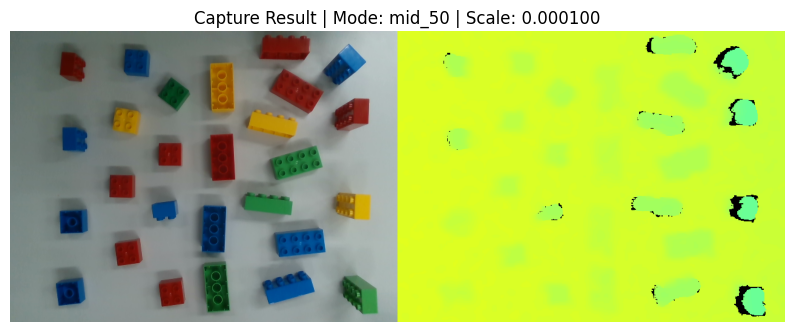

✅ 카메라 스트리밍 안전 종료 완료.


In [2]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 8비트 RGB 이미지, 16비트 뎁스, 인트린직, 뎁스 스케일 출력
# 카메라 모드 별로 설정 변경 가능

color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

color_img_bgr = color_rgb.copy()
color_img_bgr = cv2.cvtColor(color_img_bgr, cv2.COLOR_RGB2BGR)

# color_img_rgb (ndarray): RGB 포맷의 컬러 이미지 (YOLO, Open3D용)
# depth_img (ndarray): Raw 뎁스 이미지
# intrinsics (rs.intrinsics): 카메라 내부 파라미터 (3D 투영용)
# depth_scale (float): 뎁스 단위를 미터(m)로 변환하기 위한 스케일 값 (매우 중요)

# **욜로 인지**

### **YOLO V8 세그멘테이션 기준 영역 잡기**

🎯 [SUCCESS] 29개의 타겟 객체 마스크 병합 완료


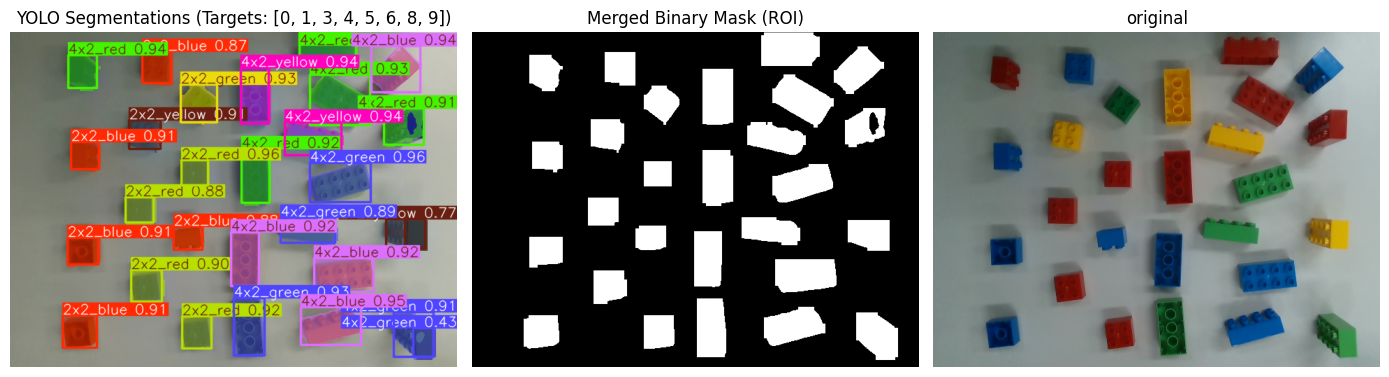

In [3]:
# color_rgb, depth, intrinsics, scale

# 욜로 검출
model = YOLO("yolo_models/duplo_2_low_2/weights/best.pt")
# model = YOLO("yolo_models/manip_segmentor_0528.pt")
target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
    model= model, 
    color_img_bgr=color_img_bgr, 
    target_classes=target_classes, 
    visualize=True
)

# results (list): YOLO 모델의 원본 추론 결과 객체 리스트
# mask_binary (ndarray): 검출된 모든 객체의 마스크를 하나로 합친 이진 마스크 (0 or 1, 형태: H x W)
# vis_yolo (ndarray): 바운딩 박스와 라벨이 그려진 시각화용 이미지 (BGR)

### 바운딩 박스가 겹치는 부분을 억제하는 전처리 추가

✂️ [INFO] 억제됨: '4x2_green' (면적:1392)가 '4x2_green' (면적:2990)에 87.6% 포함됨.
✂️ [INFO] 억제됨: '2x2_yellow' (면적:1408)가 '2x2_yellow' (면적:2396)에 99.7% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 27개
 - 🏷️ 4x2_red (신뢰도: 0.84)
 - 🏷️ 4x2_blue (신뢰도: 0.92)
 - 🏷️ 4x2_red (신뢰도: 0.93)
 - 🏷️ 4x2_yellow (신뢰도: 0.94)
 - 🏷️ 4x2_blue (신뢰도: 0.95)
 - 🏷️ 4x2_green (신뢰도: 0.93)
 - 🏷️ 4x2_red (신뢰도: 0.92)
 - 🏷️ 4x2_green (신뢰도: 0.96)
 - 🏷️ 4x2_blue (신뢰도: 0.92)
 - 🏷️ 4x2_green (신뢰도: 0.91)
 - 🏷️ 4x2_yellow (신뢰도: 0.94)
 - 🏷️ 4x2_blue (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.89)
 - 🏷️ 2x2_yellow (신뢰도: 0.77)
 - 🏷️ 2x2_blue (신뢰도: 0.91)
 - 🏷️ 4x2_red (신뢰도: 0.91)
 - 🏷️ 2x2_red (신뢰도: 0.90)
 - 🏷️ 2x2_red (신뢰도: 0.92)
 - 🏷️ 2x2_blue (신뢰도: 0.87)
 - 🏷️ 4x2_red (신뢰도: 0.94)
 - 🏷️ 2x2_yellow (신뢰도: 0.91)
 - 🏷️ 2x2_blue (신뢰도: 0.91)
 - 🏷️ 2x2_green (신뢰도: 0.93)
 - 🏷️ 2x2_blue (신뢰도: 0.91)
 - 🏷️ 2x2_red (신뢰도: 0.88)
 - 🏷️ 2x2_blue (신뢰도: 0.88)
 - 🏷️ 2x2_red (신뢰도: 0.96)


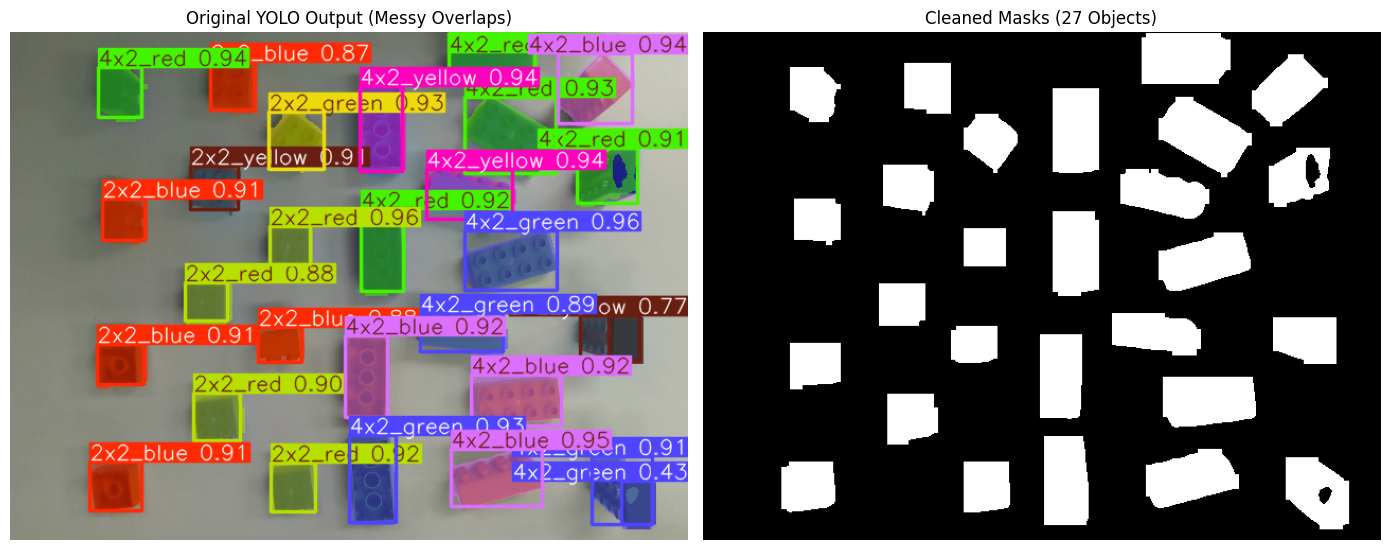

In [ ]:
# 겹치는 마스크 깔끔하게 정리 (해상도 640x480 기준, 70% 겹치면 삭제, 시각화 켬)
final_objects, clean_mask = ivl.filter_overlapping_masks(
    results=results, 
    overlap_threshold=0.70, 
    img_shape=(640, 480), 
    visualize=True
)

# final_detected_objects (list): 억제 후 살아남은 최종 객체들의 리스트. 
#                                 각 요소는 dict 형태 (class_id, class_name, confidence, mask)
# final_combined_mask (ndarray): 병합된 최종 전체 ROI 마스크 (0 or 1, uint8)

print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

### 높이 기준 거름 + 가로 세로 비율 기준 거름


[INFO] RANSAC 바닥 평면 추정 시작...
✅ 바닥 평면 방정식 도출: 0.023x + -0.003y + 1.000z + 0.530 = 0
💡 [Visualizer] 3D RANSAC 결과 창이 열립니다. (창을 닫아야 다음 코드가 진행됩니다)
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.

[INFO] 바닥 기준 40.0mm 이상 돌출된 포인트 추출 중...
✅ 40.0mm 이상 돌출된 3D 포인트 개수: 3421개


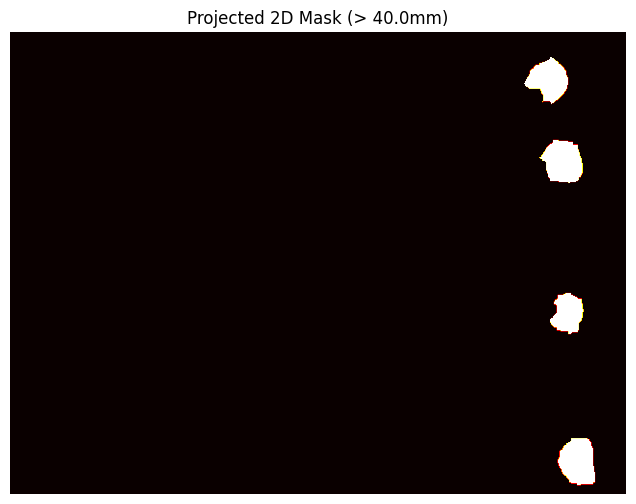


[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...


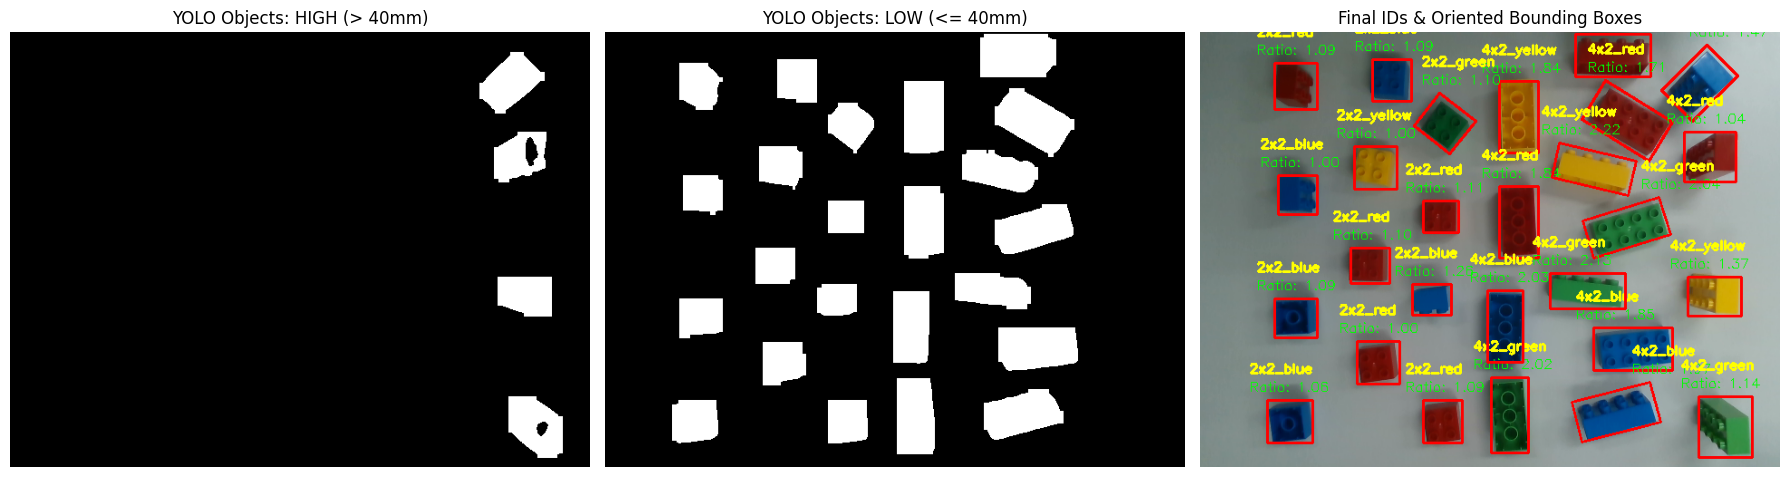


✅ 최종 검출된 유효 객체/군집 수: 27개
 - Name: 4x2_red
 - Name: 4x2_blue
 - Name: 4x2_red
 - Name: 4x2_yellow
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_red
 - Name: 4x2_green
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_yellow
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_yellow
 - Name: 2x2_blue
 - Name: 4x2_red
 - Name: 2x2_red
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_yellow
 - Name: 2x2_blue
 - Name: 2x2_green
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_red


In [ ]:
# # 1. 이전 단계에서 얻은 데이터: 
# # color_rgb, depth, intrinsics, scale
# # final_objects, clean_mask

# # [STEP 1] 바닥 평면 다림질
# plane_model, plane_normal, filtered_depth = ivl.estimate_floor_plane(
#     depth_img=depth, 
#     yolo_combined_mask=clean_mask, 
#     intrinsics=intrinsics, 
#     depth_scale=scale, 
#     depth_trunc=5.0,
#     visualize=False
# )


# # [STEP 2] 40mm 이상 돌출 맵 추출
# # 2*2 검출중 -> 세워진 4*2 수정용
# mask_40mm_2d = ivl.extract_high_objects_mask(
#     filtered_depth_img=filtered_depth, 
#     plane_normal=plane_normal, 
#     d=plane_model[3], 
#     intrinsics=intrinsics, 
#     depth_scale=scale, 
#     color_img_shape=color_img_bgr.shape, 
#     height_threshold=0.040, 
#     visualize=True
# )

# # [STEP 3] 최종 OBB 기반 ID 판독 및 교정
# # 가로 세로 비율이 1.5배 이하의 경우, 4*2 -> 2*2 수정
# final_objects, result_vis_img = ivl.correct_object_ids(
#     detected_objects=final_objects, 
#     mask_high_2d=mask_40mm_2d, 
#     color_img_bgr=color_img_bgr, 
#     ratio_threshold=1.5, 
#     overlap_threshold=0.20, 
#     visualize=True  
# )
    
# print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
# final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
# for obj in final_objects:
#     print(f" - Name: {obj['class_name']}")
#     final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

### Ransac 바닥 검출


[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: 0.023x + -0.003y + 1.000z + 0.530 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 547개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...


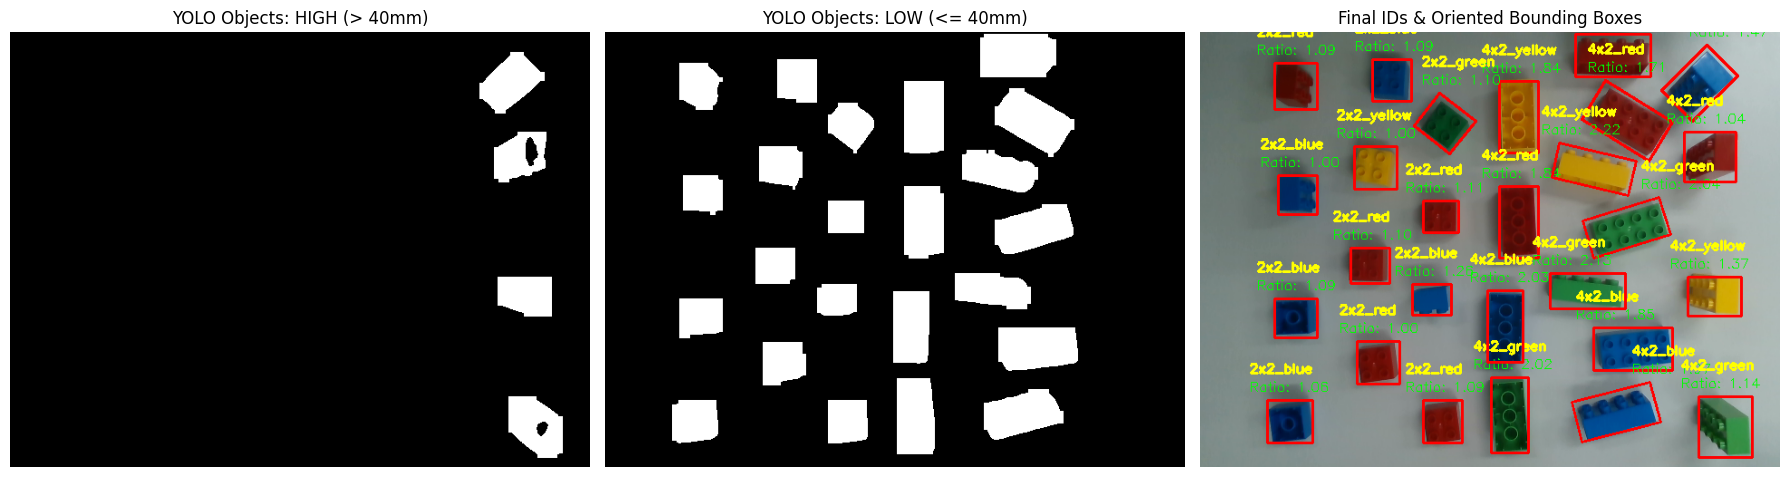


✅ 최종 검출된 유효 객체/군집 수: 27개
 - Name: 4x2_red
 - Name: 4x2_blue
 - Name: 4x2_red
 - Name: 4x2_yellow
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_red
 - Name: 4x2_green
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_yellow
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_yellow
 - Name: 2x2_blue
 - Name: 4x2_red
 - Name: 2x2_red
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_yellow
 - Name: 2x2_blue
 - Name: 2x2_green
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_red


In [ ]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
# 기존의 바닥 다림질과 돌출 맵 추출 과정이 하나의 함수로 처리됩니다.
# 반환된 closed_mask가 곧 40mm 이상 돌출된 객체의 2D 마스크(mask_40mm_2d)입니다.
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_img_bgr, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=5.0,
    height_threshold=0.040,
    visualize=False
)

print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

# =================================================================
# [STEP 3] 최종 OBB 기반 ID 판독 및 교정
# =================================================================
# 3D 마스크 추출에 성공했을 때만 YOLO 객체(final_objects)의 ID 교정을 진행합니다.
if mask_40mm_2d is not None:
    final_objects, result_vis_img = ivl.correct_object_ids(
        detected_objects=final_objects, 
        mask_high_2d=mask_40mm_2d, 
        color_img_bgr=color_img_bgr, 
        ratio_threshold=1.5, 
        overlap_threshold=0.20, 
        visualize=True   
    )
else:
    print("⚠️ 바닥 검출 또는 3D 뎁스 마스크 추출 실패로 인해 ID 교정 단계를 건너뜁니다.")


print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)


## convex hull 적용


[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: 0.023x + -0.003y + 1.000z + 0.530 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 547개

[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...
[SUCCESS] 2D 객체 마스크 복원 완료!


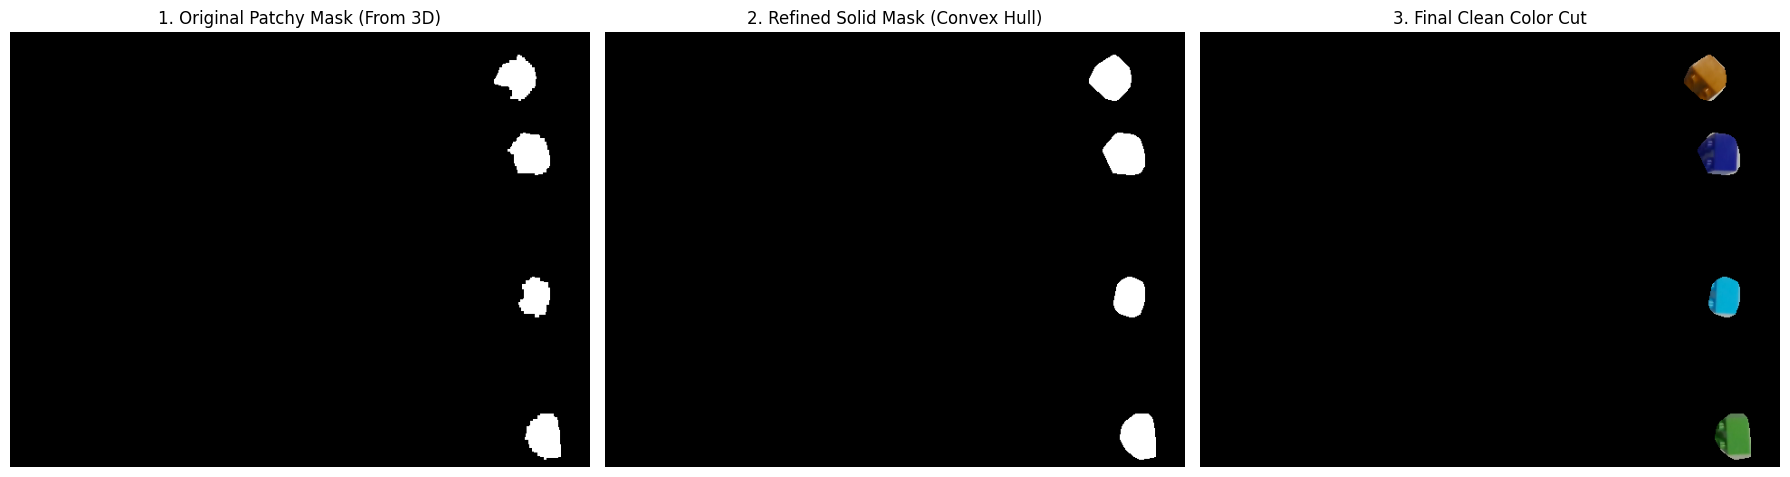


[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...


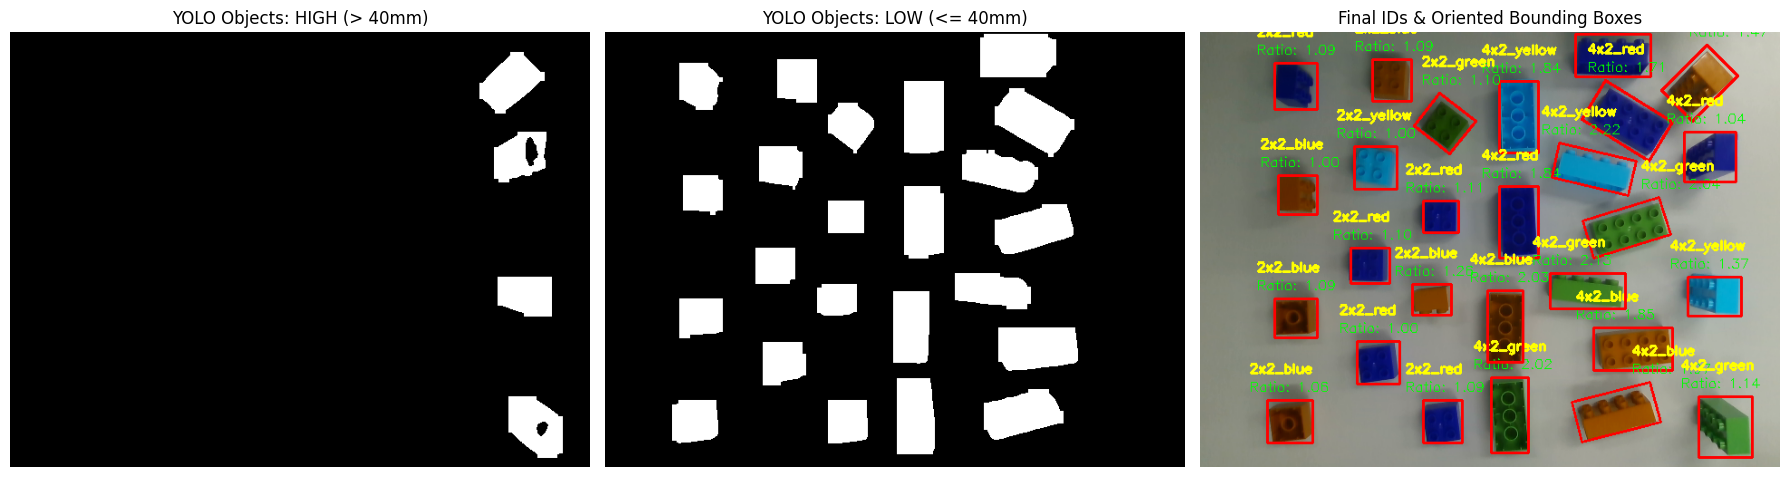

In [ ]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_img_bgr, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=3.0,
    height_threshold=0.040,         
    visualize=False  
)

# 3D 마스크 추출에 성공했을 때만 후속 작업 진행
if mask_40mm_2d is not None:
    
    # 💡 [주의] mask_40mm_2d는 현재 0과 255로 이루어져 있습니다. 
    # refine_2d_mask_with_hull 함수는 0과 1 스케일을 예상하므로 변환해서 넘겨줍니다.
    mask_40mm_01 = (mask_40mm_2d > 0).astype(np.uint8)

    # =================================================================
    # [STEP 2.5] Convex Hull을 이용한 조각난 마스크 복원
    # =================================================================
    print("\n[INFO] 조각난 2D 마스크를 Convex Hull을 이용해 복원합니다...")

    refined_mask_01, final_cut_color = ivl.refine_2d_mask_with_hull(
        projected_mask_01=mask_40mm_01, 
        color_bgr=color_rgb
    )
    print("[SUCCESS] 2D 객체 마스크 복원 완료!")

    # 📊 (선택) 복원 결과 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(mask_40mm_2d, cmap="gray")
    axes[0].set_title("1. Original Patchy Mask (From 3D)")
    axes[0].axis("off")
    axes[1].imshow(refined_mask_01, cmap="gray")
    axes[1].set_title("2. Refined Solid Mask (Convex Hull)")
    axes[1].axis("off")
    axes[2].imshow(cv2.cvtColor(final_cut_color, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Final Clean Color Cut")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    # =================================================================
    # [STEP 3] 최종 OBB 기반 ID 판독 및 교정
    # =================================================================
    # 🎯 핵심: 기존의 mask_40mm_2d 대신, 꽉 채워진 'refined_mask_01'을 넘겨줍니다.
    final_objects, result_vis_img = ivl.correct_object_ids(
        detected_objects=final_objects, 
        mask_high_2d=refined_mask_01, 
        color_img_bgr=color_rgb, 
        ratio_threshold=1.5, 
        overlap_threshold=0.20, 
        visualize=True   
    )
else:
    print("⚠️ 바닥 검출 또는 3D 뎁스 마스크 추출 실패로 인해 파이프라인을 중단합니다.")






[INFO] 3D Scene 분석 및 높이별 2D 마스크 추출 시작...

[INFO] 5mm 객체 영역을 Convex Hull로 복원합니다...

[INFO] YOLO 융합, ID 교정 및 3D 바운딩 박스 생성 중...
 🎯 [높이 강제 고정] 가장 낮은 객체('[C]4x2_yellow') 높이: 8.5mm -> 24.0mm


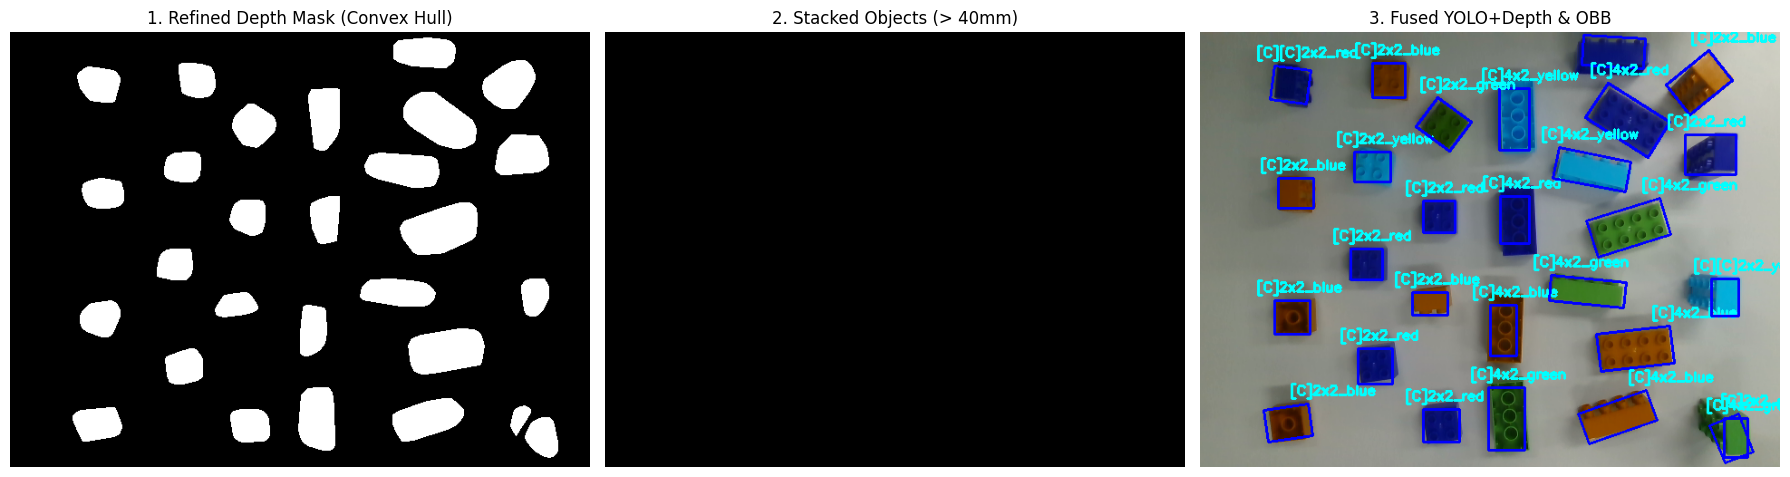


[INFO] 1번 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.
[INFO] 2번 창(원본 RGB-D 오버레이)을 엽니다.


In [9]:
# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects (YOLO 마스크 정보 포함)

# =================================================================
# [STEP 1] 3D Scene 분석 및 높이별 2D 맵 생성 (5mm, 40mm)
# =================================================================
mask_5mm_2d, mask_40mm_2d, pcd_data, plane_data, floor_pcd = ivl.process_scene_and_get_height_masks(
    depth_img=depth,
    intrinsics=intrinsics,
    depth_scale=scale,
    color_img_shape=color_rgb.shape
)

# =================================================================
# [STEP 2] Convex Hull을 이용한 5mm 객체 마스크 정밀 복원
# =================================================================
print("\n[INFO] 5mm 객체 영역을 Convex Hull로 복원합니다...")
refined_mask_01, _ = ivl.refine_2d_mask_with_hull(
    projected_mask_01=mask_5mm_2d, 
    color_bgr=color_rgb # (참고: 함수 내부에서 cv2.bitwise_and만 하므로 RGB여도 무관)
)

# =================================================================
# [STEP 3] YOLO + 3D 융합, ID 교정 및 3D OBB 생성
# =================================================================
final_objects, vis_3d, overlay_3d, vis_2d, mask_high, mask_low = ivl.fuse_yolo_and_generate_3d_obbs(
    detected_objects=final_objects,
    refined_mask_01=refined_mask_01,
    mask_40mm_2d=mask_40mm_2d,
    pcd_data=pcd_data,
    plane_data=plane_data,
    intrinsics=intrinsics,
    color_img_rgb=color_rgb,
    floor_pcd=floor_pcd
)

# =================================================================
# [STEP 4] 최종 2D/3D 결과 시각화 뷰어 띄우기
# =================================================================
ivl.visualize_final_rgbd_pointcloud(
    color_img_rgb=color_rgb,
    depth_img=depth,
    intrinsics=intrinsics,
    depth_scale=scale,
    refined_mask_01=refined_mask_01,
    mask_high_vis=mask_high,
    vis_image_2d=vis_2d,
    vis_elements_3d=vis_3d,
    overlay_geometries_3d=overlay_3d
)

# 파이프라인 종료 후, 생성된 3D OBB 및 좌표계 정보는 
# 로봇 그리퍼 Target Pose 계산을 위해 활용 가능합니다!






# import cv2
# import numpy as np
# import open3d as o3d
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm



# # =================================================================
# # 1. Depth 전처리 및 3D 점군 생성 (Single Track)
# # =================================================================
# print("\n[STEP 1] Depth 전처리 및 단일 포인트 클라우드 생성...")
# filtered_depth_img = cv2.medianBlur(depth_img, 5)

# o3d_intr = o3d.camera.PinholeCameraIntrinsic(
#     int(intrinsics.width), int(intrinsics.height),
#     float(intrinsics.fx), float(intrinsics.fy),
#     float(intrinsics.ppx), float(intrinsics.ppy)
# )
# o3d_depth_scale = 1.0 / float(depth_scale)

# depth_o3d = o3d.geometry.Image(filtered_depth_img)
# pcd = o3d.geometry.PointCloud.create_from_depth_image(
#     depth_o3d, o3d_intr, depth_scale=o3d_depth_scale, depth_trunc=1.5
# )
# pcd = pcd.voxel_down_sample(voxel_size=0.003)
# pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
# pcd, _ = pcd.remove_radius_outlier(nb_points=10, radius=0.01)

# # =================================================================
# # 2. RANSAC 바닥 검출 및 다림질
# # =================================================================
# print("\n[STEP 2] RANSAC 바닥 검출 및 평탄화(다림질)...")
# labels = np.array(pcd.cluster_dbscan(eps=0.02, min_points=20, print_progress=False))
# if len(labels) > 0 and labels.max() >= 0:
#     main_cluster_indices = np.where(labels == np.argmax(np.bincount(labels[labels >= 0])))[0]
#     floor_candidate_pcd = pcd.select_by_index(main_cluster_indices)
#     plane_model, _ = floor_candidate_pcd.segment_plane(distance_threshold=0.015, ransac_n=3, num_iterations=1000)
#     a, b, c, d = plane_model
#     plane_normal = np.array([a, b, c])
#     if c > 0:
#         plane_normal = -plane_normal
#         d = -d

# points = np.asarray(pcd.points)
# signed_height = np.dot(points, plane_normal) + d

# # 바닥 포인트 평탄화
# floor_indices = np.where(signed_height <= 0.005)[0]
# floor_pcd = pcd.select_by_index(floor_indices)
# floor_points = np.asarray(floor_pcd.points)
# distances = np.dot(floor_points, plane_normal) + d
# flattened_points = floor_points - np.outer(distances, plane_normal)
# floor_pcd.points = o3d.utility.Vector3dVector(flattened_points)
# floor_pcd.paint_uniform_color([0.8, 0.8, 0.8])

# # =================================================================
# # 3. 돌출 영역 2D 사영 및 Convex Hull 마스크 복원
# # =================================================================
# print("\n[STEP 3] 돌출 객체 2D 마스크 생성 및 Convex Hull 복원...")
# h, w = color_img_bgr.shape[:2]

# def get_projected_mask(height_threshold):
#     indices = np.where(signed_height > height_threshold)[0]
#     obj_pts = points[indices]
#     mask_2d = np.zeros((h, w), dtype=np.uint8)
#     if len(obj_pts) > 0:
#         x_3d, y_3d = obj_pts[:, 0], obj_pts[:, 1]
#         z_3d = np.where(obj_pts[:, 2] == 0, 0.00001, obj_pts[:, 2])
#         u_coords = np.round((x_3d * intrinsics.fx / z_3d) + intrinsics.ppx).astype(int)
#         v_coords = np.round((y_3d * intrinsics.fy / z_3d) + intrinsics.ppy).astype(int)
#         valid = (u_coords >= 0) & (u_coords < w) & (v_coords >= 0) & (v_coords < h)
#         mask_2d[v_coords[valid], u_coords[valid]] = 1
#     return mask_2d

# # 5mm(마스크 복원용)와 40mm(높이 판별용) 마스크 생성
# mask_5mm_2d = get_projected_mask(0.005)
# mask_40mm_2d = get_projected_mask(0.040)

# # Convex Hull을 이용해 5mm 마스크 정밀 복원
# refined_mask_01, final_cut_color = refine_2d_mask_with_hull(mask_5mm_2d, color_img_bgr)

# # =================================================================
# # 4. YOLO + Depth 융합, ID 교정 및 객체 데이터 수집
# # =================================================================
# print("\n[STEP 4] YOLO 마스크와 3D 데이터 매칭 및 높이 분석 중...")

# vis_image = color_img_bgr.copy()
# N = 1.5
# mask_high_vis = np.zeros((h, w), dtype=np.uint8)
# mask_low_vis = np.zeros((h, w), dtype=np.uint8)

# # 3D -> 2D 픽셀 맵핑 사전 준비
# z_3d_safe = np.where(points[:, 2] == 0, 0.00001, points[:, 2])
# u_all = np.round((points[:, 0] * intrinsics.fx / z_3d_safe) + intrinsics.ppx).astype(int)
# v_all = np.round((points[:, 1] * intrinsics.fy / z_3d_safe) + intrinsics.ppy).astype(int)
# valid_idx = (u_all >= 0) & (u_all < w) & (v_all >= 0) & (v_all < h)
# u_valid, v_valid = u_all[valid_idx], v_all[valid_idx]
# points_valid = points[valid_idx]
# heights_valid = signed_height[valid_idx]

# vis_elements = [floor_pcd] if 'floor_pcd' in locals() else []
# color_dict = {}
# cmap = cm.get_cmap("tab20")

# # 🌟 객체 렌더링 정보를 임시로 담아둘 리스트 생성
# object_data_list = []

# for obj in final_detected_objects:
#     yolo_mask = obj["mask"].astype(np.uint8)
    
#     # YOLO 마스크와 복원된 뎁스 마스크 교집합 적용
#     fused_mask = np.logical_and(yolo_mask > 0, refined_mask_01 > 0).astype(np.uint8)
    
#     contours, _ = cv2.findContours(fused_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     if not contours:
#         continue
        
#     largest_contour = max(contours, key=cv2.contourArea)
#     rect = cv2.minAreaRect(largest_contour)
    
#     rect_w, rect_h = rect[1]
#     ratio = max(rect_w, rect_h) / min(rect_w, rect_h) if min(rect_w, rect_h) > 0 else 0
    
#     overlap_40mm = np.logical_and(fused_mask, mask_40mm_2d)
#     overlap_ratio = np.count_nonzero(overlap_40mm) / np.count_nonzero(fused_mask)
    
#     if "original_name" not in obj:
#         obj["original_name"] = obj["class_name"]
#     old_name = obj["original_name"]
    
#     # [ID 교정 로직]
#     if overlap_ratio > 0.20:
#         mask_high_vis = np.logical_or(mask_high_vis, fused_mask).astype(np.uint8)
#         if "2x2" in old_name:
#             obj["class_name"] = f"[C]{old_name.replace('2x2', '4x2')}"
#         else:
#             obj["class_name"] = f"[C]{old_name}"
#     else:
#         mask_low_vis = np.logical_or(mask_low_vis, fused_mask).astype(np.uint8)
#         if ("4x2" in old_name or "2x4" in old_name) and ratio <= N:
#             obj["class_name"] = f"[C]{old_name.replace('4x2', '2x2').replace('2x4', '2x2')}"
#         else:
#             obj["class_name"] = f"[C]{old_name}"

#     final_id = obj["class_name"]

#     # 3D 객체 포인트 추출 및 최대 높이 계산
#     in_mask_pixels = fused_mask[v_valid, u_valid] > 0
#     obj_heights = heights_valid[in_mask_pixels]
    
#     if len(obj_heights) > 0:
#         max_h = np.percentile(obj_heights, 95)
#         max_h = max(max_h, 0.005) # 최소 5mm 보장
#     else:
#         continue # 3D 포인트가 전혀 없는 오검출 객체는 스킵

#     # 수집된 데이터를 리스트에 저장 (아직 그리지 않음)
#     object_data_list.append({
#         "final_id": final_id,
#         "rect": rect,
#         "in_mask_pixels": in_mask_pixels,
#         "max_h": max_h
#     })

# # =================================================================
# # 5. 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링
# # =================================================================
# print("\n[STEP 5] 최저 높이 객체 판별 및 바닥 밀착형 OBB 렌더링 중...")

# # 🌟 원본 컬러 포인트 클라우드에 덮어씌울 박스와 좌표계를 따로 보관할 리스트
# overlay_geometries = []

# if object_data_list:
#     # 🎯 핵심: 수집된 객체들 중 max_h가 가장 작은(가장 낮은) 객체의 인덱스 찾기
#     min_idx = min(range(len(object_data_list)), key=lambda i: object_data_list[i]["max_h"])
#     old_h = object_data_list[min_idx]["max_h"]
    
#     # 가장 낮은 객체의 높이를 24mm (0.024m)로 강제 고정
#     object_data_list[min_idx]["max_h"] = 0.024
#     print(f" 🎯 [높이 강제 고정] 가장 낮은 객체('{object_data_list[min_idx]['final_id']}')의 3D 박스 높이를 {old_h*1000:.1f}mm -> 24.0mm 로 수정했습니다.")

# for data in object_data_list:
#     final_id = data["final_id"]
#     rect = data["rect"]
#     in_mask_pixels = data["in_mask_pixels"]
#     max_h = data["max_h"]

#     if final_id not in color_dict:
#         color_dict[final_id] = cmap(len(color_dict) % 20)[:3]
#     obj_color = color_dict[final_id]

# # 3D 포인트 채색 및 추가
#     obj_pcd = o3d.geometry.PointCloud()
#     obj_pcd.points = o3d.utility.Vector3dVector(points_valid[in_mask_pixels])
#     obj_pcd.paint_uniform_color(obj_color)
#     vis_elements.append(obj_pcd)

#     # 3D OBB 및 좌표계 생성
#     box_2d = cv2.boxPoints(rect)
#     box_2d = np.intp(box_2d)
    
#     box_3d, axes_3d = create_floor_anchored_3d_box_with_axes(
#         box_2d, intrinsics, plane_normal, d, max_h, obj_color, axis_size=0.03
#     )
    
#     # 1. 기존 분석용 시각화 리스트에 추가
#     vis_elements.append(box_3d)
#     vis_elements.append(axes_3d)
    
#     # 2. 🌟 나중에 원본 RGB 맵에 덮어씌우기 위해 따로 보관
#     overlay_geometries.append(box_3d)
#     overlay_geometries.append(axes_3d)
    
#     # 2D 시각화 텍스트/박스 그리기
#     cv2.drawContours(vis_image, [box_2d], 0, (0, 0, 255), 2)
#     top_point = box_2d[np.argmin(box_2d[:, 1])]
#     cv2.putText(vis_image, final_id, (top_point[0] - 20, top_point[1] - 10), 
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

# # =================================================================
# # 6. 시각화 출력 (이후 코드는 동일)
# # =================================================================
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# axes[0].imshow(refined_mask_01, cmap="gray")
# axes[0].set_title("1. Refined Depth Mask (Convex Hull)")
# axes[0].axis("off")

# axes[1].imshow(mask_high_vis, cmap="gray")
# axes[1].set_title("2. Stacked Objects (> 40mm)")
# axes[1].axis("off")

# axes[2].imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
# axes[2].set_title("3. Fused YOLO+Depth & OBB")
# axes[2].axis("off")

# plt.tight_layout()
# plt.show()

# # 🎯 첫 번째 뷰어: 기존 분석용 3D 객체 및 바운딩 박스
# print("\n[INFO] 1번 시각화 창(분석용 색상 클러스터)을 엽니다. 창을 닫으면 원본 맵이 열립니다.")
# o3d.visualization.draw_geometries(vis_elements, window_name="1. Analytical 3D Clustered Objects & OBBs")

# # =================================================================
# # [NEW STEP] 실제 컬러가 입혀진 원본 포인트 클라우드(RGB-D) 생성 및 오버레이
# # =================================================================
# print("\n[STEP 6] 원본 컬러 포인트 클라우드 생성 및 OBB 오버레이 중...")

# # 1. BGR 이미지를 Open3D용 RGB 포맷으로 변환
# color_img_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

# # 2. Open3D Image 객체로 변환
# color_o3d = o3d.geometry.Image(color_img_rgb)
# # Median 필터링된 뎁스를 사용하여 노이즈를 줄인 원본 뎁스 맵 사용
# depth_o3d_raw = o3d.geometry.Image(filtered_depth_img)

# # 3. RGB-D 이미지 생성 (색상과 뎁스 결합)
# rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
#     color_o3d, depth_o3d_raw,
#     depth_scale=o3d_depth_scale,
#     depth_trunc=1.5,
#     convert_rgb_to_intensity=False # 흑백 변환 방지 (컬러 유지)
# )

# # 4. 카메라 파라미터를 이용해 실제 색상이 입혀진 원본 3D 포인트 클라우드 생성
# rgb_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
#     rgbd_image, o3d_intr
# )

# # 시각화 최적화를 위해 살짝 다운샘플링 (1.5mm 간격)
# # 원본 해상도를 그대로 띄우면 뷰어가 너무 무거워질 수 있습니다.
# rgb_pcd = rgb_pcd.voxel_down_sample(voxel_size=0.0015)

# # 5. 원본 포인트 클라우드 리스트에 앞서 따로 보관해둔 바운딩 박스와 좌표계 리스트를 합침
# final_overlay_elements = [rgb_pcd] + overlay_geometries

# # 🎯 두 번째 뷰어: 실제 사진 맵 + 바운딩 박스 오버레이
# print("[INFO] 2번 시각화 창(원본 RGB-D 오버레이)을 엽니다.")
# o3d.visualization.draw_geometries(final_overlay_elements, window_name="2. Real RGB-D Point Cloud with OBBs & Axes")